
---

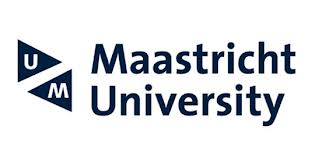

# Faculty of Science and Engineering - Department of Advanced Computer Sciences
# Course Advanced Natural Language Processing - Tutorial Tokenization

⏱️ **Estimated time:** 1.6 hours – 3.5 hours


Welcome to the tutorial about **document representation**. A fundamental challenge in Natural Language Processing is converting unstructured text into numerical representations that algorithms can process. In this notebook you will explore a progression of methods — from simple counting-based approaches to modern neural embeddings:

1. **One-Hot Encoding** — the simplest binary representation
2. **N-grams & Bag-of-Words** — counting word occurrences
3. **TF-IDF** — weighting terms by importance
4. **Cosine Similarity** — measuring document similarity
5. **Word2Vec** — learning dense word embeddings
6. **Sentence Transformers** — contextual sentence embeddings

---

## 1. One-Hot Encoding

The simplest way to represent words as numbers is **one-hot encoding**. Given a vocabulary $V = \{w_1, w_2, \ldots, w_{|V|}\}$, each word $w_i$ is represented as a binary vector $\mathbf{e}_i \in \{0, 1\}^{|V|}$ where:

$$
\mathbf{e}_i[j] = \begin{cases} 1 & \text{if } j = i \\ 0 & \text{otherwise} \end{cases}
$$

For example, with vocabulary $V = \{\text{cat}, \text{dog}, \text{fox}\}$:
- cat $\rightarrow [1, 0, 0]$
- dog $\rightarrow [0, 1, 0]$
- fox $\rightarrow [0, 0, 1]$

**Limitations:**
- Vectors are very high-dimensional (size of vocabulary, typically 10,000+)
- All word vectors are **orthogonal** — there is no notion of similarity ($\text{cosine}(\mathbf{e}_i, \mathbf{e}_j) = 0$ for $i \neq j$)
- No semantic information is captured ("king" and "queen" are as different as "king" and "banana")

In [ ]:
import numpy as np

sentence = "the quick brown fox jumps over the lazy dog"
words = sentence.split()
vocabulary = sorted(set(words))

print(f"Vocabulary ({len(vocabulary)} unique words): {vocabulary}\n")

# Create one-hot vectors for each unique word
one_hot = {word: np.eye(len(vocabulary))[i].astype(int) for i, word in enumerate(vocabulary)}

for word, vector in one_hot.items():
    print(f"  {word:6s} → {vector}")

## 2. N-grams and Bag-of-Words

Instead of representing individual words, we can capture **sequences** of words. An **n-gram** is a contiguous sequence of $n$ items from a text. Given a sequence of tokens $w_1, w_2, \ldots, w_m$, the set of n-grams is:

$$
\text{ngrams}(n) = \{(w_i, w_{i+1}, \ldots, w_{i+n-1}) \mid 1 \leq i \leq m - n + 1\}
$$

Let's see this in practice with our example sentence:

In [ ]:
sentence = "the quick brown fox jumps over the lazy dog"

A **bigram** ($n=2$) groups two consecutive words together. Bigrams capture local word co-occurrence patterns:

In [ ]:
splitted = sentence.split(" ")
[bigram for bigram in zip(splitted, splitted[1:])]

With the grouping of 3 words together, we call it a trigram.

In [ ]:
[trigram for trigram in zip(splitted, splitted[1:], splitted[2:])]

### Bag-of-Words (BoW)

A **Bag-of-Words** representation ignores word order entirely and represents a document as a vector of word counts. Given vocabulary $V = \{w_1, \ldots, w_{|V|}\}$, a document $d$ is represented as:

$$
\mathbf{d} = [\text{tf}(w_1, d), \text{tf}(w_2, d), \ldots, \text{tf}(w_{|V|}, d)]
$$

where $\text{tf}(w, d)$ is the **term frequency** — the number of times word $w$ appears in document $d$.

In [ ]:
from collections import Counter
bag_of_words = Counter(splitted)
print("Bag-of-Words representation:")
for word, count in bag_of_words.items():
    print(f"  {word}: {count}")

Notice that "the" has a count of 2, while all other words appear once. Words like "the", "a", "and" are called **stop words** — they are extremely common but carry little meaning about the document's topic. We need a weighting scheme that reduces the importance of such words. This is where **TF-IDF** comes in.

<a name="dataset"></a>

## 3. Dataset

We use a [movie review dataset](https://www.cs.cornell.edu/people/pabo/movie-review-data/) from NLTK. This dataset contains **1000 positive** and **1000 negative** movie reviews, making it suitable for **sentiment analysis** — classifying reviews as positive or negative based on their word content.

In [ ]:
import nltk
nltk.download('movie_reviews')
nltk.download('words')
from nltk.corpus import words, movie_reviews as mr
nltk_words = set(words.words())

We first remove the punctuation from all the words, and afterwards we count the most common words.

In [ ]:
import string
from collections import Counter
def remove_punct(word):
    word = word.translate(str.maketrans('', '', string.punctuation))
    return word if word in nltk_words else ''
all_words = Counter(filter(remove_punct, mr.words()))
all_words.most_common(10)

The same problem we have here. Words such as *the* and *a* are the most common amongst the movie reviews of our dataset. However, to do something with the movie review, such as classifying it, we should give a lower probability to these words, as they do not say much about the content itself.

In [ ]:
documents = [(list(filter(remove_punct, mr.words(f))), mr.categories(f)) for f in mr.fileids()]
print("Total number of documents:", len(documents))
print("Total number of words in first document:", len(documents[0][0]))

## 4. TF-IDF (Term Frequency–Inverse Document Frequency)

TF-IDF assigns a **weight** to each term in a document that reflects how important that term is relative to the collection. The score **increases** with the number of occurrences in a document and **increases** with the rarity of the term across all documents.

The TF-IDF weight of term $t$ in document $d$ is:

$$
w_{t,d} = \text{tf-idf}(t, d) = \log(1 + \text{tf}_{t,d}) \times \log_{10}\!\left(\frac{N}{\text{df}_t}\right)
$$

where:
- $\text{tf}_{t,d}$ = **term frequency**: number of times term $t$ appears in document $d$
- $\text{df}_t$ = **document frequency**: number of documents in the collection containing term $t$
- $N$ = total number of documents in the collection
- $\log(1 + \text{tf}_{t,d})$ applies **sublinear** scaling — a word appearing 10× is not 10× as important
- $\log_{10}(N / \text{df}_t)$ is the **inverse document frequency (IDF)** — rare terms get higher weight

**Key insight**: A term gets a high TF-IDF score when it appears frequently in a specific document (high TF) but rarely across the collection (high IDF). Common words like "the" will have $\text{df}_t \approx N$, giving $\text{IDF} \approx 0$.

> **Note:** There are many TF-IDF variants. A popular alternative is **BM25** (Best Matching 25), which adds document length normalization and a saturation parameter. BM25 is used by search engines like Elasticsearch and Solr.

Lets start with calculating the term frequency (tf). Now, we calculated the number of words for all documents. However, to calculate the tf-idf score we need to calculate the term-frequency for each term per document. Thus, we need to loop over the documents and count the occurrences of the terms per document.

In [ ]:
tf = [Counter(words) for words, category in documents]
tf[0].most_common(10) # Most common terms for the first document

Now let's calculate the **document frequency** ($\text{df}$). For each word in our vocabulary, we count how many documents contain that word. We convert each document to a `set` (unique words) so that membership lookup is $O(1)$ instead of $O(n)$:

In [ ]:
setted_docs = [set(doc) for doc, category in documents]
df = {word: sum([1 for doc in setted_docs if word in doc]) for word in all_words.keys()}
list(df.items())[:10]

### Computing TF-IDF from Scratch

Now let's implement the TF-IDF formula ourselves using `numpy`. For each document, we loop over its words and compute the TF-IDF weight. Notice how we use `np.log` for the sublinear TF scaling and `np.log10` for the IDF:

> **Observe**: After running this, look at which words get the highest TF-IDF scores. Are they the common words like "the" and "a", or more distinctive words?

In [ ]:
import numpy as np

N = len(documents)

# Compute TF-IDF for each word in each document
tfidf = []
for i in range(N):
    tfidf_doc = {}
    for word, count in tf[i].items():
        tfidf_doc[word] = np.log(1 + count) * np.log10(N / df[word])
    tfidf.append(tfidf_doc)

# Check: print top 5 TF-IDF terms for the first document
sorted_first = sorted(tfidf[0].items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 TF-IDF terms for document 1:")
for word, score in sorted_first:
    print(f"  {word}: {score:.4f}")

# Compare with a common word
if "the" in tfidf[0]:
    print(f"\n  'the' TF-IDF: {tfidf[0]['the']:.4f}  ← very low because it appears in nearly every document")

### Comparing TF-IDF across Positive and Negative Reviews

Let's see whether positive and negative movie reviews use distinctive words. We compute the **average TF-IDF** per word separately for positive and negative reviews:

> **Observe**: Look at the top words for each sentiment. Do you see sentiment-related words ("great", "bad") or mostly movie-related words ("film", "story")? What does this tell us about using TF-IDF for classification?

In [ ]:
# Separate positive and negative documents
pos_indices = [i for i, (_, cat) in enumerate(documents) if 'pos' in cat]
neg_indices = [i for i, (_, cat) in enumerate(documents) if 'neg' in cat]

# Average TF-IDF per word for positive reviews
pos_avg = {}
for i in pos_indices:
    for word, score in tfidf[i].items():
        pos_avg[word] = pos_avg.get(word, 0) + score
pos_avg = {w: s / len(pos_indices) for w, s in pos_avg.items()}

# Average TF-IDF per word for negative reviews
neg_avg = {}
for i in neg_indices:
    for word, score in tfidf[i].items():
        neg_avg[word] = neg_avg.get(word, 0) + score
neg_avg = {w: s / len(neg_indices) for w, s in neg_avg.items()}

top_positive = sorted(pos_avg.items(), key=lambda x: x[1], reverse=True)[:20]
top_negative = sorted(neg_avg.items(), key=lambda x: x[1], reverse=True)[:20]

print("Top 20 words in POSITIVE reviews:")
for word, score in top_positive:
    print(f"  {word}: {score:.4f}")

print("\nTop 20 words in NEGATIVE reviews:")
for word, score in top_negative:
    print(f"  {word}: {score:.4f}")

# Find words unique to each list
pos_words = set(w for w, _ in top_positive)
neg_words = set(w for w, _ in top_negative)
print(f"\nWords only in positive top-20: {pos_words - neg_words}")
print(f"Words only in negative top-20: {neg_words - pos_words}")
print(f"Shared words: {pos_words & neg_words}")

### Why the Logarithm Is a Natural Fit for NLP

The **log function** appears throughout NLP and Information Retrieval. Understanding *why* is important for grasping TF-IDF, Naive Bayes, perplexity, and many other formulas.

#### Reason 1: Language follows Zipf's Law (power-law distribution)
Word frequencies in natural language follow a **power law**: a few words are extremely frequent ("the", "is"), while most words are very rare. Raw frequencies span several orders of magnitude (from millions to single occurrences). The **log** compresses this dynamic range:

$$\log(1{,}000{,}000) = 6, \quad \log(1) = 0$$

This is exactly what TF-IDF's IDF component does: $\text{IDF}(t) = \log\frac{N}{\text{df}(t)}$ compresses the huge range of document frequencies into a manageable scale.

#### Reason 2: Dampening high-frequency terms in TF
The raw term frequency of common words can be 100× higher than informative words. Applying log to TF (sublinear TF): $\text{tf}_{\log} = 1 + \log(\text{tf})$ ensures that a word appearing 100 times is not treated as 100× more important than a word appearing once — the relationship becomes logarithmic rather than linear. This prevents common words from dominating similarity calculations.

#### Reason 3: Converting products to sums (Naive Bayes, HMMs)
In probabilistic models like **Naive Bayes** and **HMMs**, we compute products of many probabilities:

$$P(w_1, w_2, ..., w_n | c) = \prod_{i=1}^{n} P(w_i | c)$$

Two critical benefits of taking the log:
1. **Numerical stability**: Multiplying many small probabilities causes **underflow** (numbers too small for floating-point representation). Logs convert products to sums: $\log \prod P_i = \sum \log P_i$
2. **Computational efficiency**: Addition is faster than multiplication, and sums are easier to work with mathematically

#### Reason 4: Information-theoretic foundation
The log has deep connections to **information theory**. The information content of an event with probability $p$ is $-\log_2(p)$ bits. Rare events (low $p$) carry more information. This connects directly to:
- **Entropy**: $H = -\sum p \log p$ (average information)
- **Perplexity**: $\text{PP} = 2^{H}$ (how "surprised" a model is)
- **Cross-entropy loss**: The standard training loss for language models

### Visualizing TF-IDF Weights

Let's visualize how TF-IDF assigns different weights to words. We use scikit-learn's `TfidfVectorizer` to compute TF-IDF on a small set of example documents and display the result as a heatmap:

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Small example corpus
example_docs = [
    "the cat sat on the mat",
    "the dog chased the cat",
    "the fox jumped over the lazy dog",
    "a quick brown fox"
]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(example_docs)
feature_names = vectorizer.get_feature_names_out()

# Create a DataFrame for visualization
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names,
                        index=[f"Doc {i+1}" for i in range(len(example_docs))])

plt.figure(figsize=(12, 4))
sns.heatmap(tfidf_df, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title("TF-IDF Weights per Document")
plt.ylabel("Documents")
plt.xlabel("Terms")
plt.tight_layout()
plt.show()

print("\nNotice how common words like 'the' get lower weights,")
print("while distinctive words like 'mat', 'jumped', 'quick' get higher weights.")

## 5. Cosine Similarity

Once we have vector representations of documents (whether BoW, TF-IDF, or embeddings), we need a way to measure **how similar** two documents are. The most commonly used measure in IR is **cosine similarity**.

For two vectors $\mathbf{a}$ and $\mathbf{b}$, cosine similarity is defined as:

$$
\text{cos}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|} = \frac{\sum_{i=1}^{n} a_i \, b_i}{\sqrt{\sum_{i=1}^{n} a_i^2} \cdot \sqrt{\sum_{i=1}^{n} b_i^2}}
$$

- The result ranges from $-1$ (opposite) to $1$ (identical direction), with $0$ meaning orthogonal (unrelated).
- For non-negative vectors (like TF-IDF), the range is $[0, 1]$.
- Cosine similarity measures **angle**, not magnitude — a long document and a short document with the same word proportions will have high similarity.

Let's compute the cosine similarity between our example TF-IDF documents:

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Compute pairwise cosine similarity on TF-IDF vectors
cos_sim = cosine_similarity(tfidf_matrix)
cos_df = pd.DataFrame(cos_sim, 
                       index=[f"Doc {i+1}" for i in range(len(example_docs))],
                       columns=[f"Doc {i+1}" for i in range(len(example_docs))])

plt.figure(figsize=(6, 5))
sns.heatmap(cos_df, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1, linewidths=0.5)
plt.title("Cosine Similarity between Documents (TF-IDF)")
plt.tight_layout()
plt.show()

print("Documents:")
for i, doc in enumerate(example_docs):
    print(f"  Doc {i+1}: \"{doc}\"")
print("\nDoc 1 and Doc 2 share 'the' and 'cat' → moderate similarity")
print("Doc 3 and Doc 4 share 'fox' → some similarity")
print("Doc 1 and Doc 4 share nothing meaningful → low similarity")

## 6. Word2Vec — Dense Word Embeddings

So far, our representations have been **sparse** and **high-dimensional** (one dimension per vocabulary word). Word2Vec (Mikolov et al., 2013) learns **dense, low-dimensional** vectors (typically 100-300 dimensions) where **semantically similar words are close together** in vector space.

The core idea is the **distributional hypothesis**: *"A word is characterized by the company it keeps."* (Firth, 1957)

Word2Vec has two training architectures:

1. **Skip-gram**: Given a center word $w_t$, predict context words $w_{t+j}$ within a window of size $c$. The objective maximizes:

$$
\frac{1}{T} \sum_{t=1}^{T} \sum_{-c \leq j \leq c, \, j \neq 0} \log P(w_{t+j} \mid w_t)
$$

where 

$$
P(w_O \mid w_I) = \frac{\exp(\mathbf{v}'_{w_O} \cdot \mathbf{v}_{w_I})}{\sum_{w=1}^{|V|} \exp(\mathbf{v}'_w \cdot \mathbf{v}_{w_I})}
$$

2. **CBOW (Continuous Bag of Words)**: Given context words, predict the center word. Faster to train but less effective on rare words.

In practice, **negative sampling** is used instead of the full softmax to make training tractable.

The most common implementation for Word2Vec in Python is [gensim](https://radimrehurek.com/gensim/models/word2vec.html). Let's train Word2Vec on our movie reviews:

In [ ]:
from gensim.models import Word2Vec
model = Word2Vec(sentences=[doc for doc, cat in documents])
word_vectors = model.wv
word_vectors['the']

We can find the most similar vector nearby a word using `most_similar`.

In [ ]:
word_vectors.most_similar('king')

And we can even do arithmetic with it. The most famous example of this is the `king + man - woman = queen` analogy. By adding the vector of king and man to each other, and subtracting the vector of woman, we should get the queen vector. Lets try!

In [ ]:
word_vectors.most_similar(positive=['king','woman'],negative=['man'])

We get queen as the second most similar vector. We only trained our word2vec model on our reviews dataset which is a small dataset for word2vec standards, so that makes sense.

Lastly, lets plot the data. For this, we need to represent our vectors as a 2-d space. For this, we need a dimensionality reduction technique, such as PCA or t-SNE. We use t-SNE (invented by someone who did the same master as you are doing!). It might take a while to compute the vectors below:

In [ ]:
from sklearn.manifold import TSNE
import numpy as np
tsne = TSNE(n_components=2, random_state=0)
vectors = tsne.fit_transform(np.asarray(model.wv.vectors))
x, y = zip(*vectors)

In [ ]:
len(x), len(y)

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 12))
plt.scatter(x, y)

## 7. Pretrained Word Embeddings (GloVe)

Word2Vec works best with **pretrained embeddings** — vectors trained on massive corpora by researchers and made publicly available.

**GloVe** (Global Vectors, Pennington et al., 2014) is a popular alternative to Word2Vec. While Word2Vec uses local context windows, GloVe combines:
- **Global co-occurrence statistics** (how often words appear together across the entire corpus)  
- **Local context** (word-word co-occurrence within windows)

GloVe optimizes the objective:

$$
J = \sum_{i,j=1}^{|V|} f(X_{ij}) \left( \mathbf{w}_i^T \tilde{\mathbf{w}}_j + b_i + \tilde{b}_j - \log X_{ij} \right)^2
$$

where $X_{ij}$ is the co-occurrence count and $f$ is a weighting function that prevents very common co-occurrences from dominating.

Let's download pretrained GloVe vectors (trained on Wikipedia + Gigaword, 6B tokens):

In [ ]:
import gensim.downloader
glove = gensim.downloader.load('glove-wiki-gigaword-50')

In [ ]:
glove["king"]

### Sentiment Classification with GloVe

Let's see how well GloVe embeddings can be used for sentiment classification. The approach:

1. For each document, get the GloVe vector for every word (skip words not in the vocabulary)
2. **Average** all word vectors to create a single document embedding
3. Split into 80/20 train/test
4. Train a `LogisticRegression` classifier

> **Observe**: Note the libraries we use (`train_test_split`, `LogisticRegression`, `accuracy_score`) and how we handle words missing from the GloVe vocabulary. Also note how we average word vectors with `np.mean(vectors, axis=0)` — this is a common technique to get a document-level representation from word embeddings.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create averaged GloVe vectors for each document
X_glove = []
y_labels = []
for words, categories in documents:
    word_vectors = [glove[w] for w in words if w in glove]   # skip unknown words
    if word_vectors:
        X_glove.append(np.mean(word_vectors, axis=0))        # average all word vectors
    else:
        X_glove.append(np.zeros(50))  # fallback: zero vector for GloVe-50d
    y_labels.append(1 if 'pos' in categories else 0)

X_glove = np.array(X_glove)
y_labels = np.array(y_labels)

print(f"Document matrix shape: {X_glove.shape}  (2000 docs × 50 dimensions)")

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_glove, y_labels, test_size=0.2, random_state=42
)

# Train a Logistic Regression classifier
clf_glove = LogisticRegression(max_iter=1000, random_state=42)
clf_glove.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf_glove.predict(X_test)
glove_accuracy = accuracy_score(y_test, y_pred)
print(f"GloVe + LogisticRegression — Accuracy: {glove_accuracy:.4f}\n")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

> **Why not just accuracy?** With imbalanced classes, accuracy is misleading — a model predicting only the majority class scores high but is useless. **Precision** (of positive predictions, how many are correct?), **Recall** (of actual positives, how many found?), and **F1** (harmonic mean) reveal per-class performance. For a full treatment of these metrics, see **Tutorial 03**.

## Bias in Word2Vec
One of the problems with Word2Vec (and with machine learning in general) is that there is lots of biases assumed by the model. Examples of biases that can be harmful when using these algorithms include gender bias and ethnicity bias. Lets check for example what happens if we take the female equivalent of `doctor`:

In [ ]:
glove.most_similar(positive=['doctor','woman'],negative=['man'])

### Exploring Bias in Word Embeddings

Word embeddings learn associations from training data — including societal biases present in that data. Let's explore **gender bias** and **professional stereotypes** using analogy queries.

> **Observe**: Look at the analogy results below. What patterns do you notice? Are these associations factual, or do they reflect harmful stereotypes?

**Why do these biases exist?**

Word embeddings are trained on large corpora of web text, news articles, and books that reflect historical and societal prejudices. When these embeddings are used in downstream applications — such as search engines, chatbots, hiring tools, or criminal justice risk assessment — they can **perpetuate and amplify discrimination**.

For example, if a resume-screening system uses GloVe embeddings that associate "programmer" more closely with "man" than "woman", it may systematically rank male candidates higher. This is an active area of research in **AI fairness** and **debiasing** (Bolukbasi et al., 2016).

In [ ]:
# Example 1: Gender bias in professions
print("man:programmer :: woman:?")
print(glove.most_similar(positive=['programmer', 'woman'], negative=['man'])[:5])

print("\nman:doctor :: woman:?")
print(glove.most_similar(positive=['doctor', 'woman'], negative=['man'])[:5])

# Example 2: Professional stereotypes
print("\nfather:doctor :: mother:?")
print(glove.most_similar(positive=['doctor', 'mother'], negative=['father'])[:5])

### Debiasing Word Embeddings

Identifying bias is important, but an advanced NLP practitioner should also know how to **mitigate** it. The most influential approach is **projection-based debiasing** (Bolukbasi et al., 2016), which works in three steps:

1. **Identify the bias direction** — compute a "gender direction" vector from gendered word pairs (he/she, man/woman, king/queen)
2. **Project it out** — for neutral words (e.g., "programmer", "nurse"), remove the component along the gender direction
3. **Verify** — check that the debiased vectors no longer associate professions with gender

This is conceptually similar to **orthogonal projection** in linear algebra: we find the subspace that encodes bias and project all word vectors onto the complementary subspace.

In [ ]:
# Projection-based debiasing (Bolukbasi et al., 2016)
import numpy as np

# Step 1: Compute the gender direction from definitionally gendered word pairs
gender_pairs = [
    ('he', 'she'), ('man', 'woman'), ('boy', 'girl'),
    ('king', 'queen'), ('brother', 'sister'), ('father', 'mother'),
    ('husband', 'wife'), ('son', 'daughter')
]

# The gender direction = average difference between male and female words
diffs = [glove[m] - glove[f] for m, f in gender_pairs]
gender_direction = np.mean(diffs, axis=0)
gender_direction = gender_direction / np.linalg.norm(gender_direction)  # normalize

print(f"Gender direction vector (first 10 dims): {gender_direction[:10].round(3)}")
print()

# Step 2: Measure bias BEFORE debiasing
def gender_bias_score(word, gender_dir, embeddings):
    """How much does a word align with the gender direction? (positive = male, negative = female)"""
    vec = embeddings[word]
    return float(np.dot(vec, gender_dir) / np.linalg.norm(vec))

neutral_words = ['programmer', 'nurse', 'engineer', 'teacher', 'doctor', 
                 'scientist', 'secretary', 'pilot', 'receptionist', 'architect']

print(f"{'Word':<15} {'Bias Score (before)':>20}  Direction")
print("-" * 55)
for w in neutral_words:
    score = gender_bias_score(w, gender_direction, glove)
    direction = '← female' if score < 0 else 'male →'
    print(f"{w:<15} {score:>20.4f}  {direction}")

In [ ]:
# Step 3: Debias by projecting out the gender direction
def debias_word(word_vec, gender_dir):
    """Remove the gender component from a word vector."""
    projection = np.dot(word_vec, gender_dir) * gender_dir
    return word_vec - projection

# Create debiased vectors for neutral words
print(f"{'Word':<15} {'Before':>10} {'After':>10} {'Reduction':>10}")
print("-" * 50)
for w in neutral_words:
    before = gender_bias_score(w, gender_direction, glove)
    debiased = debias_word(glove[w], gender_direction)
    after = float(np.dot(debiased, gender_direction) / np.linalg.norm(debiased))
    reduction = abs(before) - abs(after)
    print(f"{w:<15} {before:>10.4f} {after:>10.4f} {reduction:>10.4f}")

print()
print("After debiasing, all bias scores are near zero.")
print("The words retain their professional meaning but lose the gender association.")

### Limitations of Projection-Based Debiasing

While this technique reduces measurable bias, it has important limitations:

- **Only addresses one axis at a time** — debiasing for gender doesn't fix racial, age, or other biases
- **Intersectional bias** (e.g., Black women) requires more sophisticated approaches
- **Bias may persist in higher-order statistics** that simple projection doesn't capture (Gonen & Goldberg, 2019)
- **Contextual models** (BERT, GPT) require different debiasing strategies since each word has multiple context-dependent vectors

We will revisit bias and interpretability in **Tutorial 10 (XAI in NLP)**, where we examine how transformer attention patterns reveal and encode biases, and explore model-level debiasing strategies.

## 8. Sentence Transformers — Contextual Embeddings

A key limitation of Word2Vec and GloVe is that they produce **static embeddings** — each word has exactly one vector regardless of context. The word "bank" gets the same vector whether it means "river bank" or "financial bank".

**Transformer-based models** (like BERT) solve this by producing **contextual embeddings** — the vector for each word depends on its surrounding context. These models use the **self-attention mechanism**:

$$
\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right) V
$$

where $Q$, $K$, $V$ are query, key, and value matrices derived from input embeddings, and $d_k$ is the dimension of the keys.

**Sentence Transformers** (Reimers & Gurevych, 2019) extend BERT by applying **mean pooling** over all token embeddings to produce a single fixed-size vector for an entire sentence. This is efficient and well-suited for tasks like:
- Semantic search
- Sentence similarity
- Clustering
- Sentiment classification

| Feature | Word2Vec / GloVe | Sentence Transformers |
|:--------|:-----------------|:---------------------|
| Type | Static | Contextual |
| Granularity | Word-level | Sentence-level |
| Polysemy | One vector per word | Context-dependent |
| Training data | Co-occurrence | Masked language model |
| Typical dims | 50–300 | 384–1024 |

Let's load a sentence transformer model:

In [ ]:
from sentence_transformers import SentenceTransformer
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')

We can encode any sentence like this:

In [ ]:
sentence_embedding = sentence_model.encode("the quick brown fox jumps over the lazy dog")
sentence_embedding.shape

We now get a vector of 384 instead of a matrix of 11 by 768. This makes it much easier to deal with.

### Sentiment Classification with Sentence Transformers

Let's repeat the same sentiment classification task using **Sentence Transformers** instead of GloVe. The key differences are:

1. We join each word list into a full sentence string
2. `sentence_model.encode()` produces a single 384-d vector per document (no manual averaging needed)
3. We use the same Logistic Regression setup for a fair comparison

> **Observe**: Compare the Precision, Recall, and F1-score with the GloVe classifier above. Why do we look at these metrics instead of only accuracy? Which representation performs better and why?

In [ ]:
# Convert documents to sentence strings
doc_strings = [" ".join(words) for words, cat in documents]

# Encode with sentence transformers (produces 384-d vectors directly)
X_st = sentence_model.encode(doc_strings, show_progress_bar=True)

# Same labels as before
X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
    X_st, y_labels, test_size=0.2, random_state=42
)

# Train classifier
clf_st = LogisticRegression(max_iter=1000, random_state=42)
clf_st.fit(X_train_st, y_train_st)

# Predict and evaluate
y_pred_st = clf_st.predict(X_test_st)
st_accuracy = accuracy_score(y_test_st, y_pred_st)
print(f"Sentence Transformers + LogisticRegression — Accuracy: {st_accuracy:.4f}\n")
print(classification_report(y_test_st, y_pred_st, target_names=["negative", "positive"]))

**Why does Sentence Transformers outperform GloVe?**

Sentence Transformers typically achieve higher accuracy than GloVe for several reasons:
1. **Contextual embeddings** capture word meaning in context, while GloVe uses static vectors
2. **Sentence-level representations** from mean pooling capture the overall meaning, rather than simply averaging word vectors
3. **Pre-training on NLI tasks** makes sentence transformers better at understanding semantic relationships

To further improve accuracy, we could fine-tune the sentence transformer on our specific dataset, use a larger model (e.g., `all-mpnet-base-v2`), or fine-tune BERT end-to-end.

## Handling Long Documents

Standard Sentence Transformer models have a **maximum input length** (256–512 tokens). Real-world documents are often much longer. Common strategies:

| Strategy | Max Length | Preserves All Content? | Complexity |
|:---------|:----------|:----------------------|:-----------|
| **Truncation** | 256–512 tokens | No | Trivial |
| **Chunking + Mean Pool** | Unlimited | Yes (averaged) | Low |
| **Hierarchical Encoding** | Unlimited | Yes (structured) | Medium |
| **Long-context model** | 8K–128K tokens | Yes (native) | Low |

Modern models like **ModernBERT** (2024, 8192 tokens with RoPE + Flash Attention) handle long documents natively without chunking workarounds.

In [ ]:
# Strategy 2: Chunking with Mean Pooling
# Split long text into overlapping chunks, encode each, average the results

import numpy as np

def encode_long_text(text, model, max_tokens=256, overlap=50):
    """Encode a long text by chunking with overlap and averaging embeddings."""
    words = text.split()
    
    if len(words) <= max_tokens:
        return model.encode(text)
    
    # Create overlapping chunks
    chunks = []
    start = 0
    while start < len(words):
        chunk = " ".join(words[start:start + max_tokens])
        chunks.append(chunk)
        start += max_tokens - overlap
    
    # Encode all chunks and average
    chunk_embeddings = model.encode(chunks)
    return np.mean(chunk_embeddings, axis=0)

# Demo: compare truncation vs chunking on a long review
long_review = " ".join(doc_strings[:5])  # Concatenate 5 reviews to simulate a long document
print(f"Long document: {len(long_review.split())} words")
print()

# Truncation: just encode (model silently truncates)
trunc_embedding = sentence_model.encode(long_review)

# Chunking: encode all content
chunk_embedding = encode_long_text(long_review, sentence_model)

# How different are the results?
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity([trunc_embedding], [chunk_embedding])[0][0]
print(f"Cosine similarity between truncated vs. chunked: {similarity:.4f}")
print(f"A similarity < 1.0 means truncation loses information from later parts of the document.")

### Modern Long-Context Models

| Model | Year | Max Tokens | Key Innovation |
|:------|:-----|:-----------|:---------------|
| **BERT** | 2018 | 512 | Absolute positional embeddings |
| **Longformer** | 2020 | 4,096 | Sliding window + global attention |
| **ModernBERT** | 2024 | 8,192 | RoPE + Flash Attention |

> For a detailed explanation of attention mechanisms, see **Tutorial 07**.

In [ ]:
# Example: Using a long-context embedding model
# GTE-ModernBERT supports up to 8192 tokens natively
#
# Uncomment to install and run (requires GPU with sufficient memory):
# !pip install sentence-transformers>=3.0
#
# from sentence_transformers import SentenceTransformer
# long_model = SentenceTransformer("Alibaba-NLP/gte-modernbert-base")
#
# # This model handles up to 8192 tokens — no chunking needed for most documents
# long_embedding = long_model.encode(long_review)
# print(f"GTE-ModernBERT embedding shape: {long_embedding.shape}")  # (768,)
# print(f"Max sequence length: {long_model.max_seq_length}")  # 8192

# For comparison with our earlier models:
print("Model comparison for document embedding:")
print(f"  all-MiniLM-L6-v2:  max {sentence_model.max_seq_length} tokens, {sentence_model.get_sentence_embedding_dimension()}d vectors")
print(f"  GTE-ModernBERT:    max 8192 tokens, 768d vectors")
print()
print("When to use which:")
print("  - Short texts (<256 tokens): MiniLM is faster and sufficient")
print("  - Medium texts (256-512):    Consider all-mpnet-base-v2 (768d, 512 tokens)")
print("  - Long documents (512+):     Use GTE-ModernBERT or chunking strategy")

---

## Exercises

Now that you have seen all the document representation methods and their library implementations, answer the following exercises to check your understanding.

### Exercise 1 — Understanding Document Representations (3 points)

Answer the following questions in your own words:

1. **TF-IDF vs. Bag-of-Words**: Why does TF-IDF give a lower weight to the word "the" compared to a rare domain-specific word like "cinematography"? Explain using the formulas you saw in Section 4.

2. **Static vs. contextual embeddings**: The word "bank" can mean a *river bank* or a *financial institution*. Explain how Word2Vec/GloVe and Sentence Transformers handle this differently, and what the practical consequence is for downstream tasks like search or classification.

3. **Document averaging**: In the GloVe classifier demo, we averaged all word vectors in a document to get a single vector. What information is lost by this averaging, and how do Sentence Transformers address this limitation?

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

### Exercise 2 — Bias and Fairness in Embeddings (3 points)

You saw in Section 7 that GloVe encodes societal biases. Answer the following:

1. **Come up with 2 new bias examples**: Using `glove.most_similar(positive=[...], negative=[...])`, demonstrate at least **two new bias analogies** that we did **not** show in the demo (e.g., racial bias, age bias, nationality stereotypes). Show your code and results.

2. **Static vs. contextual bias**: Do you think Sentence Transformers (contextual models) also suffer from bias? Why or why not? What is fundamentally different about how they learn word associations?

3. **Mitigation**: Suggest one concrete technique that could reduce bias in word embeddings used for a job-matching application.

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

### Exercise 3 — TF-IDF Sentiment Classifier (4 points)

In the demos above, you saw classifiers built with **GloVe** and **Sentence Transformers**. Now build a sentiment classifier using **TF-IDF** representations:

1. Use `TfidfVectorizer` from scikit-learn to transform the movie review documents into TF-IDF vectors
2. Split the data 80/20 with `random_state=42`
3. Train a `LogisticRegression(max_iter=1000, random_state=42)` classifier
4. Store predictions as `y_pred_tfidf`
5. Print both the **accuracy** and the full `classification_report` (Precision, Recall, F1) — compare these with the GloVe and Sentence Transformer results

> **Hint**: You'll need to convert each document (list of words) to a string first, similar to what you saw in the Sentence Transformers demo. Look at how `TfidfVectorizer` was used in Section 4 for the heatmap. Use `accuracy_score` and `classification_report` from `sklearn.metrics` as shown in the demos above.

In [ ]:
### BEGIN SOLUTION
# YOUR CODE HERE
raise NotImplementedError()
### END SOLUTION

tfidf_accuracy = accuracy_score(y_test_tfidf, y_pred_tfidf)
print(f"TF-IDF + LogisticRegression — Accuracy: {tfidf_accuracy:.4f}\n")
print(classification_report(y_test_tfidf, y_pred_tfidf, target_names=["negative", "positive"]))

### Exercise 4 — Why Does TF-IDF Beat Dense Embeddings Here? (3 points)

Look at the results from the three classifiers above (TF-IDF, GloVe, Sentence Transformers). You may notice that the "simplest" representation — TF-IDF — actually achieves the **highest** accuracy and F1-score. This is counter-intuitive: shouldn't more sophisticated models perform better?

Answer the following questions:

1. **TF-IDF advantage**: Why might TF-IDF + Logistic Regression outperform GloVe averaging for sentiment classification specifically? Think about how each representation handles individual sentiment-bearing words like "terrible", "masterpiece", or "boring".

2. **GloVe averaging weakness**: When we average all word vectors in a document into a single 50-d vector, what information is lost? Consider what happens when a review has 300 neutral words and 5 strongly negative words.

3. **Sentence Transformer limitations**: The model `all-MiniLM-L6-v2` has a maximum input length of ~256 tokens. Movie reviews are often much longer. How does this affect performance compared to TF-IDF, which sees *all* words? Also, this model was pre-trained on sentence similarity tasks — not sentiment. How would fine-tuning change the result?

4. **General lesson**: What does this tell you about the relationship between model complexity and task performance? When should you use simple baselines vs. deep learning?

### BEGIN SOLUTION
YOUR ANSWER HERE
### END SOLUTION

## Embedding Efficiency and Deployment Tradeoffs

When deploying NLP systems at scale, the choice of document representation has significant implications for **memory**, **speed**, and **cost**. Here we compare the representations covered in this tutorial for a realistic scenario: encoding **1 million documents**.

In [ ]:
# Practical comparison: memory and computation tradeoffs at scale
import sys

n_docs = 1_000_000

# Representation parameters
representations = [
    {
        'name': 'TF-IDF (sparse)',
        'dims': 10_000,
        'bytes_per_value': 8,   # float64
        'sparsity': 0.99,       # 99% zeros (sparse storage)
        'encode_speed': '~50,000 docs/sec',
        'similarity_speed': 'Fast (sparse dot product)',
        'gpu_required': 'No',
    },
    {
        'name': 'Word2Vec/GloVe (avg)',
        'dims': 300,
        'bytes_per_value': 4,   # float32
        'sparsity': 0.0,        # dense
        'encode_speed': '~20,000 docs/sec',
        'similarity_speed': 'Very fast (small dense)',
        'gpu_required': 'No',
    },
    {
        'name': 'Sentence Transformers (MiniLM)',
        'dims': 384,
        'bytes_per_value': 4,   # float32
        'sparsity': 0.0,
        'encode_speed': '~1,000 docs/sec (GPU)',
        'similarity_speed': 'Fast (small dense)',
        'gpu_required': 'Recommended',
    },
    {
        'name': 'Sentence Transformers (mpnet)',
        'dims': 768,
        'bytes_per_value': 4,
        'sparsity': 0.0,
        'encode_speed': '~500 docs/sec (GPU)',
        'similarity_speed': 'Fast (dense)',
        'gpu_required': 'Recommended',
    },
    {
        'name': 'ModernBERT (GTE, 8K context)',
        'dims': 768,
        'bytes_per_value': 4,
        'sparsity': 0.0,
        'encode_speed': '~200 docs/sec (GPU)',
        'similarity_speed': 'Fast (dense)',
        'gpu_required': 'Yes',
    },
]

print(f"Memory footprint for {n_docs:,} documents:")
print(f"{'Representation':<35} {'Dims':>8} {'Memory (GB)':>12} {'Encode Speed':>25} {'GPU?':>8}")
print("-" * 92)

for rep in representations:
    effective_values = rep['dims'] * (1 - rep['sparsity'])
    memory_bytes = n_docs * effective_values * rep['bytes_per_value']
    memory_gb = memory_bytes / (1024**3)
    print(f"{rep['name']:<35} {rep['dims']:>8,} {memory_gb:>11.2f}  {rep['encode_speed']:>24} {rep['gpu_required']:>8}")

print()
print("Key takeaways:")
print("  - TF-IDF is sparse: only ~1% non-zero, so actual memory is small despite high dimensionality")
print("  - Dense embeddings (300-768d) are compact and fast for similarity search")
print("  - The bottleneck for transformer models is ENCODING speed, not storage")
print("  - For billion-scale retrieval, consider dimensionality reduction or quantization")

### When to Use What in Practice

| Scenario | Best Representation | Why |
|:---------|:-------------------|:----|
| Quick prototype, small data | TF-IDF | Fast, no GPU, interpretable features |
| Keyword-heavy task (e.g., topic classification) | TF-IDF | Lexical features dominate |
| Semantic similarity / search | Sentence Transformers | Captures meaning beyond keywords |
| Long documents (legal, medical) | ModernBERT / chunking | Handles 8K+ tokens natively |
| Billion-scale retrieval | MiniLM + quantization | Small vectors (384d), fast encoding |
| Multimodal (text + images) | CLIP / aligned embeddings | Shared embedding space (Tutorial 12) |

Understanding these tradeoffs becomes critical when we discuss **multimodal models** (Tutorial 12), where text and image embeddings must share a common space, and **agents** (Tutorial 16), where retrieval-augmented generation (RAG) depends on fast, accurate document retrieval.

## 9. Summary — Comparison of Document Representation Methods

| Method | Type | Dimensions | Captures Semantics? | Handles Polysemy? | Key Advantage | Key Limitation |
|:-------|:-----|:-----------|:--------------------|:-----------------|:-------------|:--------------|
| **One-Hot** | Sparse, binary | size of vacabulary (10K+) | No | No | Simple, interpretable | No similarity between words |
| **Bag-of-Words** | Sparse, count | size of vacabulary | No | No | Captures word frequency | Ignores word order and importance |
| **TF-IDF** | Sparse, weighted | size of vacabulary | Partially | No | Weights by importance | Still high-dimensional, no semantics |
| **Word2Vec** | Dense, static | 100–300 | Yes | No | Captures analogies and similarity | One vector per word |
| **GloVe** | Dense, static | 50–300 | Yes | No | Combines global + local statistics | One vector per word |
| **Sentence Transformers** | Dense, contextual | 384–1024 | Yes | Yes | Context-aware, sentence-level | Computationally expensive |
| **ModernBERT / Long-context** | Dense, contextual | 768–1024 | Yes | Yes | Handles 8K+ tokens natively | Requires GPU, large model |

**The evolution**: From sparse, high-dimensional, context-free representations → dense, low-dimensional, context-aware embeddings. Each step captures more linguistic information but requires more computational resources.